#HW3 - PyTorch Tutorial

Amanda Yaklin (yaklin2@illinois.edu) 10/5/2026

In [1]:
import torch
import numpy as np

# 1. Intro to tensors
data = [[1,2],[3,4]]
x_data = torch.tensor(data)
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n{x_ones}\n")
x_rand = torch.rand_like(x_data, dtype=torch.float)
print(f"Random Tensor \n{x_rand}\n")
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)
print(f"Random Tensor:\n{rand_tensor}\n")
print(f"Ones Tensor:\n{ones_tensor}\n")
print(f"Zeros Tensor:\n{zeros_tensor}\n")
tensor = torch.rand(3,4)
print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

# move to GPU
try:
    device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
    tensor = torch.linspace(0,10,11)
    tensor = tensor.to(device)
    print(f"Device tensor is stored on: {tensor.device}")
    print(f"Linspace:\n {tensor}")
    tensor = torch.full(shape,2)
    print(f"Full:\n{tensor}")
except AttributeError:
    print("no GPU acceleration available\n")

# compute element-wise product
print(f"tensor.mul(tensor)\n{tensor.mul(tensor)}")
print(f"tensor*tensor\n{tensor*tensor}")

# compute tensor product
print(f"tensor.matmul(tensor.T)\n{tensor.matmul(tensor.T)}")
print(f"tensor@tensor.T\n{tensor@tensor.T}")
print(tensor,"\n")

# addition
tensor.add_(5)
print(tensor)
t=torch.ones(5)
print(f"t: {t}")

# numpy bridge
n = t.numpy()
print(f"n: {n}")
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")
n = np.ones(5)
t = torch.from_numpy(n)
np.add(n, 4, out=n)
print(f"t: {t}")
print(f"n: {n}")

Ones Tensor: 
tensor([[1, 1],
        [1, 1]])

Random Tensor 
tensor([[0.8519, 0.4217],
        [0.1658, 0.4920]])

Random Tensor:
tensor([[0.8822, 0.0310, 0.5898],
        [0.3202, 0.3324, 0.4875]])

Ones Tensor:
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Zeros Tensor:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu
Device tensor is stored on: cpu
Linspace:
 tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])
Full:
tensor([[2, 2, 2],
        [2, 2, 2]])
tensor.mul(tensor)
tensor([[4, 4, 4],
        [4, 4, 4]])
tensor*tensor
tensor([[4, 4, 4],
        [4, 4, 4]])
tensor.matmul(tensor.T)
tensor([[12, 12],
        [12, 12]])
tensor@tensor.T
tensor([[12, 12],
        [12, 12]])
tensor([[2, 2, 2],
        [2, 2, 2]]) 

tensor([[7, 7, 7],
        [7, 7, 7]])
t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]
t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]
t: tensor([5., 5

In [2]:
# 2. Intro to torch.autograd
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
print("torch version", torch.__version__)
print("torchvision version", torchvision.__version__)
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1,3,64,64) # 64x64 3-channel random image
labels = torch.rand(1, 1000)


torch version 2.14.1+cpu
torchvision version 0.29.1+cpu


In [3]:
prediction = model(data) # forward pass
loss = (prediction - labels).sum() # error in prediction
loss.backward() # backward pass
# stochastic gradient descent with momentum
# momentum means this optimizer uses *exponential weighted averages* 
# these are biased to favor more recent observations over older ones
# the "momentum" tells us how about how many points the average is taken over
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9) 
optim.step() # gradient descent

a=torch.tensor([2.,3.],requires_grad=True)
b=torch.tensor([6.,4.],requires_grad=True)
Q = 3*a**3 - b**2 # cost function
# dQ/da = 9a^2
# dQ/db = -2b
# these gradients are calculated and stored via Q.backward(gradient)
ext_gradient = torch.tensor([1.,1.])
Q.backward(gradient = ext_gradient)
# the results match the expected gradients
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


In [4]:
# 3. Neural nets

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super().__init__()
        # convolution 1: 1 input image, 6 output channels, 5x5 square kernel
        self.conv1 = nn.Conv2d(1,6,5)
        # convolution 2: 6 input channels, 16 output channels, 5x5 square kernel
        self.conv2 = nn.Conv2d(6,16,5)
        # affine operation y=Wx+b
        # nn.Linear(size of input sample, size of output sample)
        self.fc1 = nn.Linear(16*5*5,120) # 5*5 = image dimension
        self.fc2 = nn.Linear(120, 84) 
        self.fc3 = nn.Linear(84,10)
    
    def forward(self, input):
        # * convolution layer c1: *
        # 1 input, 6 ouputs, 5x5 square kernel
        # ReLU activation function (ramp function)
        # output: tensor with size (N,6,28,28); N=batch size
        c1 = F.relu(self.conv1(input))
        # * subsampling layer s2: *
        # 2x2 grid, no parameter, outputs tensor with size (N,6,14,14)
        s2 = F.max_pool2d(c1, (2,2))
        # * convolution layer c3: *
        # 6 inputs, 16 outputs, 5x5 square kernel
        # ReLU activation function
        # output: tensor with size (N,16,10,10)
        c3 = F.relu(self.conv2(s2))
        # * subsampling layer s4: *
        # 2x2 grid, no parameter, outputs tensor with size (N,16,5,5)
        s4 = F.max_pool2d(c3, 2)
        # * flattening operation: *
        # outputs (N,400) tensor
        s4 = torch.flatten(s4, 1)
        # * fully connected layer f5 * 
        # input (N,400) tensor
        # output (N,120) tensor
        # ReLU activation function
        f5 = F.relu(self.fc1(s4))
        # * fully connected layer f6 *
        # input (N,120)
        # output (N,84)
        # ReLU activation function
        f6 = F.relu(self.fc2(f5))
        # * fully connected layer OUTPUT *
        # input (N,84)
        # output (N,10)
        output = self.fc3(f6)
        return output
net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [5]:
params = list(net.parameters())
print(len(params))
print(params[0].size()) # weight of conv1

10
torch.Size([6, 1, 5, 5])


In [6]:
# test random input 32x32
inp = torch.randn(1,1,32,32)
out = net(inp)
print(out)

tensor([[ 0.1255,  0.0615, -0.0051, -0.2111,  0.0996,  0.1336, -0.1505, -0.0747,
          0.1445,  0.0294]], grad_fn=<AddmmBackward0>)


In [7]:
# zero the gradient buffers of parameters and random-gradient backdrops
net.zero_grad()
out.backward(torch.randn(1,10))

In [8]:
# loss function
# how far from the target is our prediction?
output = net(inp)
target = torch.randn(10) # dummy target
target = target.view(1,-1) # same shape as output
criterion = nn.MSELoss() # common loss function (mean squared error)
loss = criterion(output, target)
print(loss)

tensor(1.2101, grad_fn=<MseLossBackward0>)


In [9]:
print(loss.grad_fn) # MSE loss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU

In [10]:
# backpropagation (how the weights influence error)
# uses gradient of loss function w.r.t. weights to determine the direction
# in which to modify the weight (positive or negative) to minimize loss
net.zero_grad()
print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)
loss.backward()
print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0048,  0.0042,  0.0013, -0.0126,  0.0076,  0.0014])


In [11]:
# modify weights using stochastic gradient descent
learning_rate = 0.01
for f in net.parameters():
    with torch.no_grad():
        f -= f.grad * learning_rate

In [12]:
# built-in tool enables us to use different methods
import torch.optim as optim
optimizer = optim.SGD(net.parameters(), lr=0.01) # create optimizer

# in our training loop:
optimizer.zero_grad() # zero gradient buffers
output = net(inp)
loss = criterion(output, target) # loss function
loss.backward() # backprop
optimizer.step() # updates

In [13]:
# Training a Classifier
from torchvision.transforms import v2
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True), # image tensor values in [0,1]
    v2.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # args: sequence of means and stds for the channels
])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%


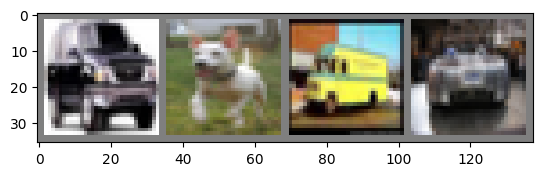

car   dog   truck car  


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [27]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(12, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [28]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
epochs = 2

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.162
[1,  4000] loss: 1.824
[1,  6000] loss: 1.644
[1,  8000] loss: 1.546
[1, 10000] loss: 1.455
[1, 12000] loss: 1.412
[2,  2000] loss: 1.333
[2,  4000] loss: 1.317
[2,  6000] loss: 1.279
[2,  8000] loss: 1.254
[2, 10000] loss: 1.214
[2, 12000] loss: 1.211
Finished Training


In [29]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

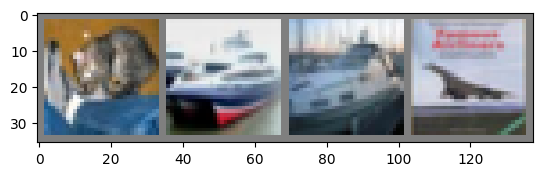

GroundTruth:  cat   ship  ship  plane


In [30]:
# check whether learning was successful

# fist establish ground truth

dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


In [31]:
# now see what the neural net thinks these images are
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [32]:
outputs=net(images)
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  cat   ship  ship  plane


In [33]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 57 %


In [34]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 78.3 %
Accuracy for class: car   is 59.9 %
Accuracy for class: bird  is 38.9 %
Accuracy for class: cat   is 25.4 %
Accuracy for class: deer  is 51.6 %
Accuracy for class: dog   is 58.4 %
Accuracy for class: frog  is 49.5 %
Accuracy for class: horse is 69.1 %
Accuracy for class: ship  is 64.6 %
Accuracy for class: truck is 78.3 %


In [35]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

net.to(device)
inputs, labels = data[0].to(device),data[1].to(device)

cpu
